In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('telecom_churn_mock_data.csv')
df

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST1000,Male,0,No,No,30,Yes,Yes,No,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),69.55,2047.01,No
1,CUST1001,Female,0,No,Yes,11,Yes,Yes,Fiber optic,No internet service,...,No,No internet service,No,No internet service,Month-to-month,Yes,Electronic check,48.08,522.42,No
2,CUST1002,Female,1,No,No,17,No,No,Fiber optic,No,...,No,No,Yes,No,Two year,No,Electronic check,36.56,610.07,No
3,CUST1003,Female,0,Yes,No,26,Yes,No,No,No,...,No,No,No,No,One year,Yes,Bank transfer (automatic),79.72,2159.26,No
4,CUST1004,Male,0,Yes,Yes,23,Yes,No,Fiber optic,No internet service,...,No,Yes,No,Yes,Month-to-month,Yes,Mailed check,70.42,1672.56,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CUST2995,Female,0,No,Yes,72,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,No,Bank transfer (automatic),74.29,5206.46,No
1996,CUST2996,Female,0,No,Yes,34,Yes,No,DSL,No internet service,...,No internet service,No,No internet service,No,Month-to-month,Yes,Mailed check,120.00,3951.13,No
1997,CUST2997,Male,0,No,No,57,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,No,Electronic check,82.28,4805.18,No
1998,CUST2998,Male,0,No,No,19,Yes,No,No,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,84.09,1642.44,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        2000 non-null   object 
 1   Gender            2000 non-null   object 
 2   SeniorCitizen     2000 non-null   int64  
 3   Partner           2000 non-null   object 
 4   Dependents        2000 non-null   object 
 5   Tenure            2000 non-null   int64  
 6   PhoneService      2000 non-null   object 
 7   MultipleLines     2000 non-null   object 
 8   InternetService   2000 non-null   object 
 9   OnlineSecurity    2000 non-null   object 
 10  OnlineBackup      2000 non-null   object 
 11  DeviceProtection  2000 non-null   object 
 12  TechSupport       2000 non-null   object 
 13  StreamingTV       2000 non-null   object 
 14  StreamingMovies   2000 non-null   object 
 15  Contract          2000 non-null   object 
 16  PaperlessBilling  2000 non-null   object 


In [5]:
df.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df['Churn'].value_counts()

Churn
No     1321
Yes     679
Name: count, dtype: int64

In [7]:
df.isnull().sum()

CustomerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: xlabel='Churn'>

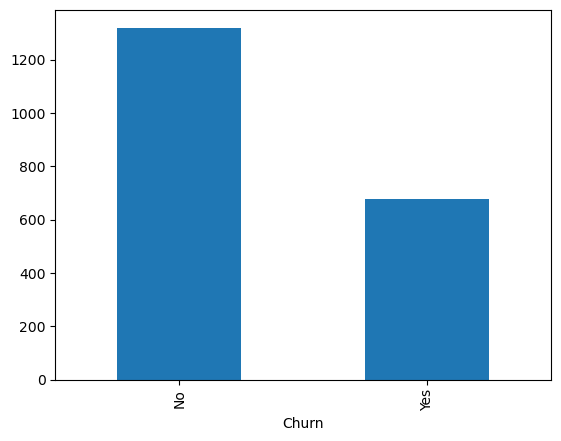

In [8]:
df['Churn'].value_counts().plot(kind='bar')

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


Churn Counts:
 Churn
No     1321
Yes     679
Name: count, dtype: int64

Churn %:
 Churn
No     66.05
Yes    33.95
Name: proportion, dtype: float64


C:\Users\SCS-AI-HASSAN-AHMED\AppData\Local\Temp\ipykernel_10184\2483192199.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


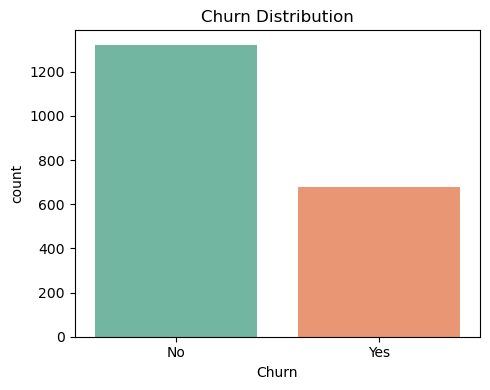

In [10]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn Counts:\n", churn_counts)
print("\nChurn %:\n", churn_pct.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.tight_layout()
plt.show()

In [11]:
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.151500,36.342500,65.880710,2394.132725
std,0.358625,21.029392,27.154716,1807.861046
min,0.000000,1.000000,18.000000,18.000000
25%,0.000000,18.000000,45.342500,934.712500
50%,0.000000,37.000000,65.460000,1972.770000
75%,0.000000,54.000000,84.992500,3532.675000
max,1.000000,72.000000,120.000000,8756.020000


In [12]:
print("Duplicate rows:", df.duplicated().sum())
print("Unique CustomerIDs:", df['CustomerID'].nunique())

Duplicate rows: 0
Unique CustomerIDs: 2000


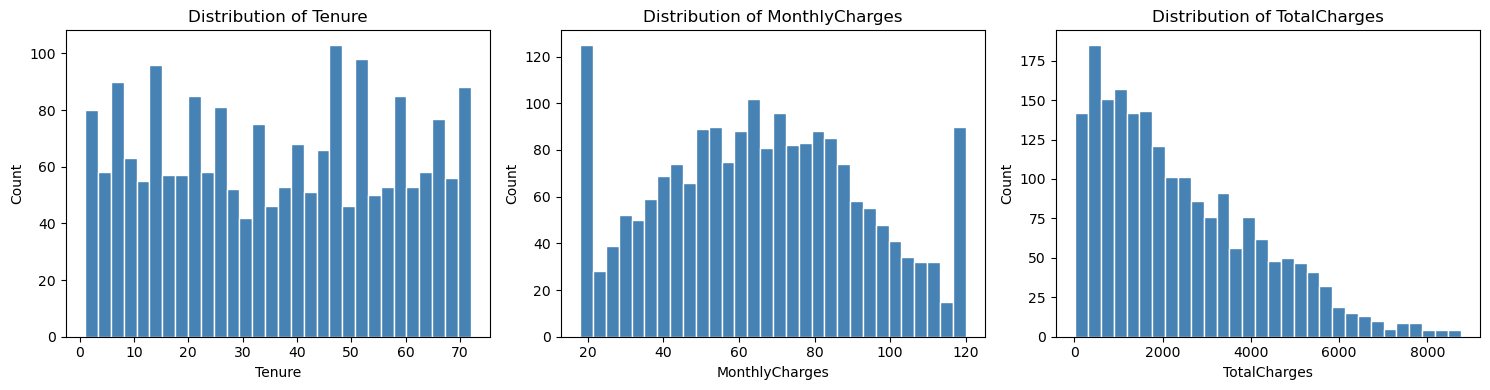

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Tenure', 'MonthlyCharges', 'TotalCharges']):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

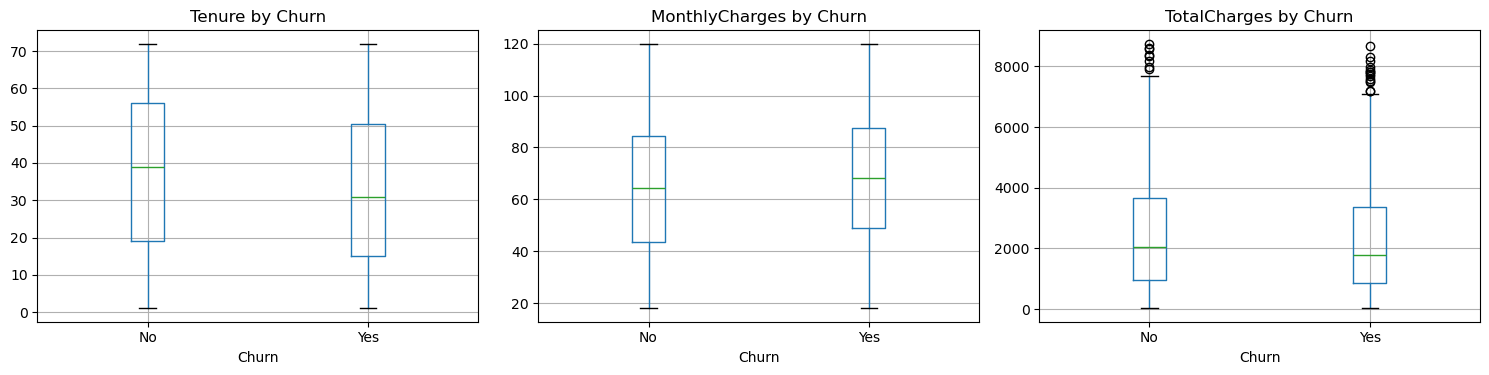

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Tenure', 'MonthlyCharges', 'TotalCharges']):
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel('Churn')

plt.suptitle('')
plt.tight_layout()
plt.show()

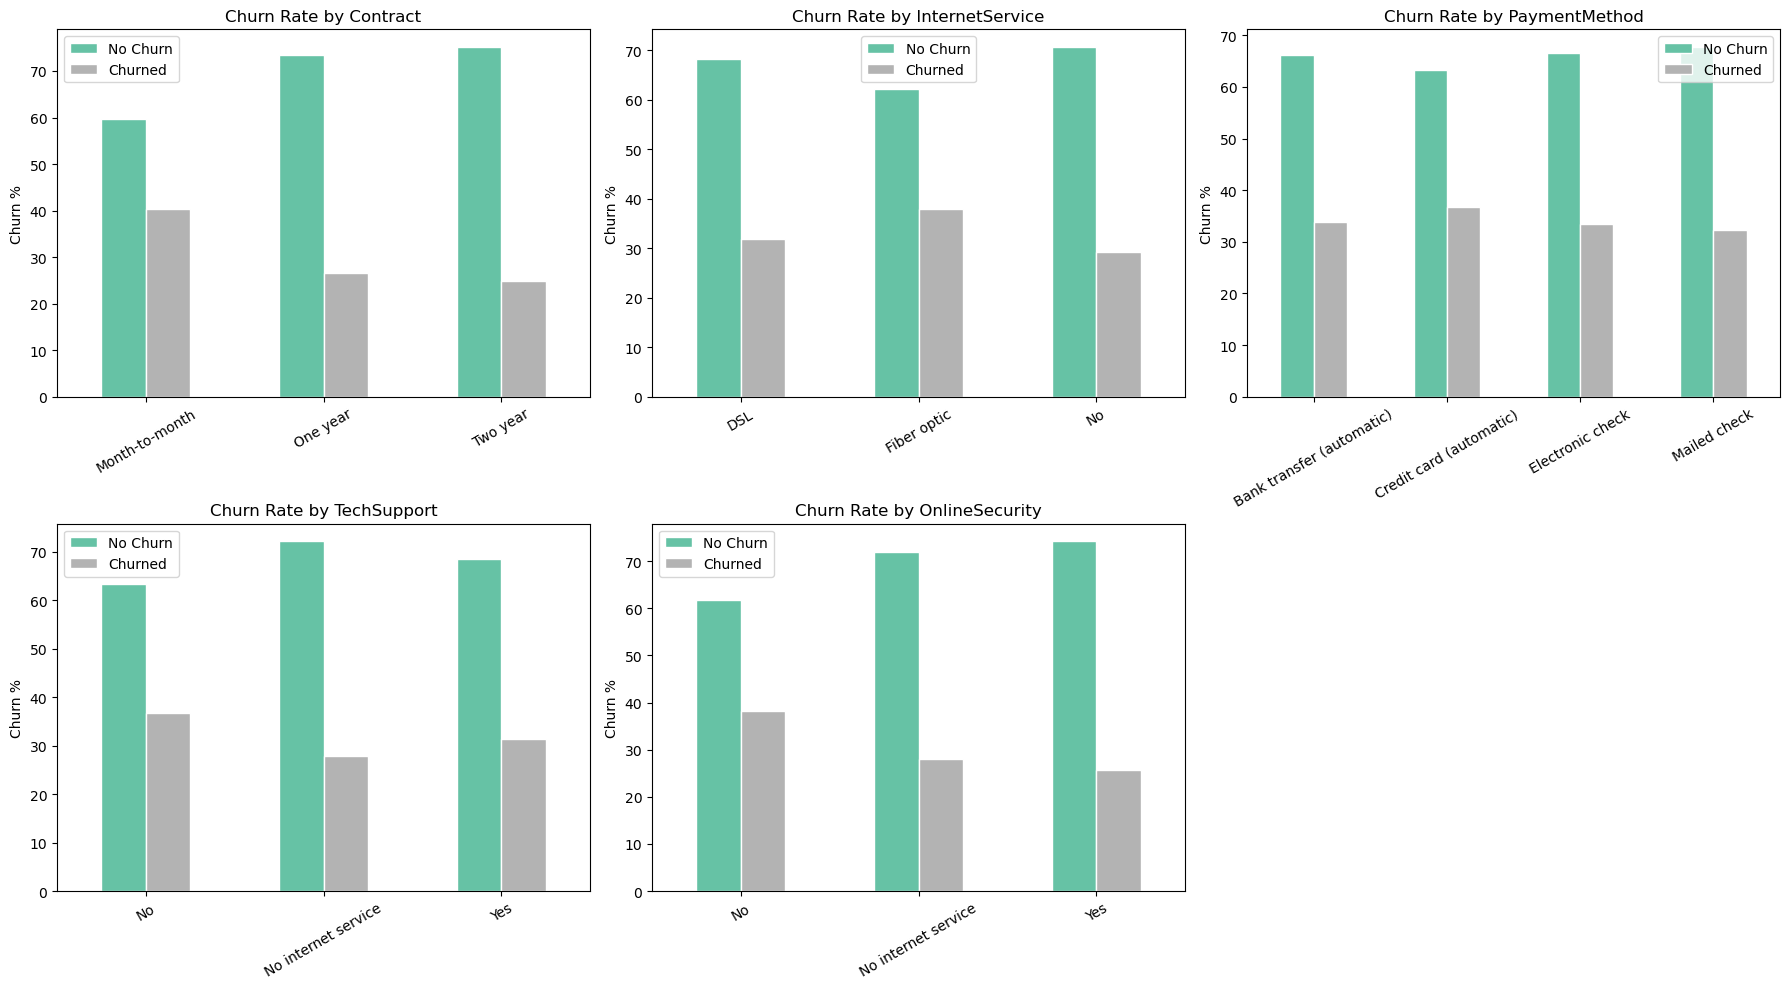

In [15]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn %')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['No Churn', 'Churned'])

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

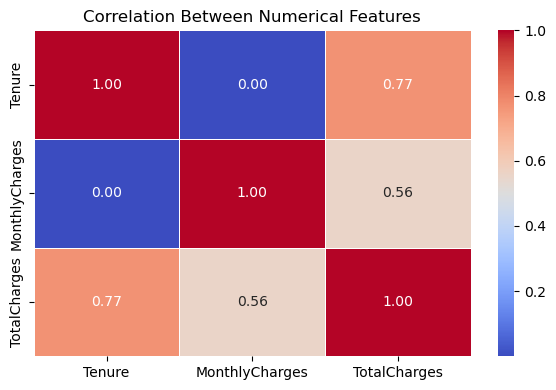

In [16]:
plt.figure(figsize=(6, 4))
corr = df[['Tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Numerical Features')
plt.tight_layout()
plt.show()

In [17]:
df = df.drop(columns=['CustomerID'])
print("Dropped CustomerID. New shape:", df.shape)

Dropped CustomerID. New shape: (2000, 20)


In [18]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn value counts:\n", df['Churn'].value_counts())

Churn value counts:
 Churn
0    1321
1     679
Name: count, dtype: int64


In [19]:
# TotalCharges / Tenure gives average monthly spend over lifetime
# Avoid division by zero for tenure = 0
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['Tenure'] + 1)

print(df[['Tenure', 'TotalCharges', 'MonthlyCharges', 'AvgMonthlySpend']].head())

   Tenure  TotalCharges  MonthlyCharges  AvgMonthlySpend
0      30       2047.01           69.55        66.032581
1      11        522.42           48.08        43.535000
2      17        610.07           36.56        33.892778
3      26       2159.26           79.72        79.972593
4      23       1672.56           70.42        69.690000


In [20]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling', 'MultipleLines']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print(df[binary_cols].head())

   Partner  Dependents  PhoneService  PaperlessBilling  MultipleLines
0        0           0             1                 0            1.0
1        0           1             1                 1            1.0
2        0           0             0                 0            0.0
3        1           0             1                 1            0.0
4        1           1             1                 1            0.0


In [21]:
# These are effectively just "No" — replace them
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_cols:
    df[col] = df[col].replace('No internet service', 'No')
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print(df[internet_cols].head())

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             0                 0            0            0   
1               0             0                 0            0            0   
2               0             1                 0            0            1   
3               0             0                 0            0            0   
4               0             0                 0            1            0   

   StreamingMovies  
0                0  
1                0  
2                0  
3                0  
4                1  


In [22]:
multi_cols = ['Gender', 'InternetService', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("Columns:\n", list(df.columns))

Shape after encoding: (2000, 25)
Columns:
 ['SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AvgMonthlySpend', 'Gender_Male', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [25]:
# Check what unique values exist
print("MultipleLines unique values:", df['MultipleLines'].unique())
print("NaN count:", df['MultipleLines'].isnull().sum())

MultipleLines unique values: [ 1.  0. nan]
NaN count: 191


In [26]:
# "No phone service" means the customer has no phone → treat as 0
df['MultipleLines'] = df['MultipleLines'].fillna(0).astype(int)

# Verify
print("Fixed. Unique values:", df['MultipleLines'].unique())
print("NaN count:", df['MultipleLines'].isnull().sum())

Fixed. Unique values: [1 0]
NaN count: 0


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))
print("Any nulls?", X_train.isnull().sum().sum())

Train: (1600, 24) | Test: (400, 24)
Train churn rate: 0.339
Test churn rate: 0.34
Any nulls? 0


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

lr  = LogisticRegression(random_state=42, max_iter=1000)
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='logloss', verbosity=0)

models = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall'   : round(recall_score(y_test, y_pred), 3),
        'F1 Score' : round(f1_score(y_test, y_pred), 3),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.677      0.566   0.221     0.317    0.620
      Random Forest     0.637      0.385   0.110     0.171    0.574
            XGBoost     0.610      0.381   0.235     0.291    0.569


In [30]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("Imports done.")

Imports done.


In [32]:
# This tells the ANN to penalize missing a churner more than missing a non-churner
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("Class weights:", class_weight_dict)
# Weight for class 1 (Churner) should be ~2x higher than class 0

Class weights: {0: np.float64(0.7568590350047304), 1: np.float64(1.4732965009208103)}


In [33]:
model = Sequential([
    # Input layer
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Hidden layer 1
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Hidden layer 2
    Dense(16, activation='relu'),
    Dropout(0.2),
    
    # Output layer — sigmoid for binary classification
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\SCS-AI-HASSAN-AHMED\miniconda3\envs\machine_learning\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 192 (768.00 B)

In [34]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,          # stop if val_loss doesn't improve for 10 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete.")

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6453 - loss: 0.8902 - val_accuracy: 0.5719 - val_loss: 0.6798
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6008 - loss: 0.7947 - val_accuracy: 0.4594 - val_loss: 0.7087
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5633 - loss: 0.7731 - val_accuracy: 0.4219 - val_loss: 0.7215
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5758 - loss: 0.7089 - val_accuracy: 0.4094 - val_loss: 0.7275
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5875 - loss: 0.7054 - val_accuracy: 0.3969 - val_loss: 0.7274
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5523 - loss: 0.7039 - val_accuracy: 0.4094 - val_loss: 0.7248
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5852 - loss: 0.6842 - val_accuracy: 0.4281 - val_loss: 0.7228
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5844 - loss: 0.6738 - val_accuracy: 0.4563 - 

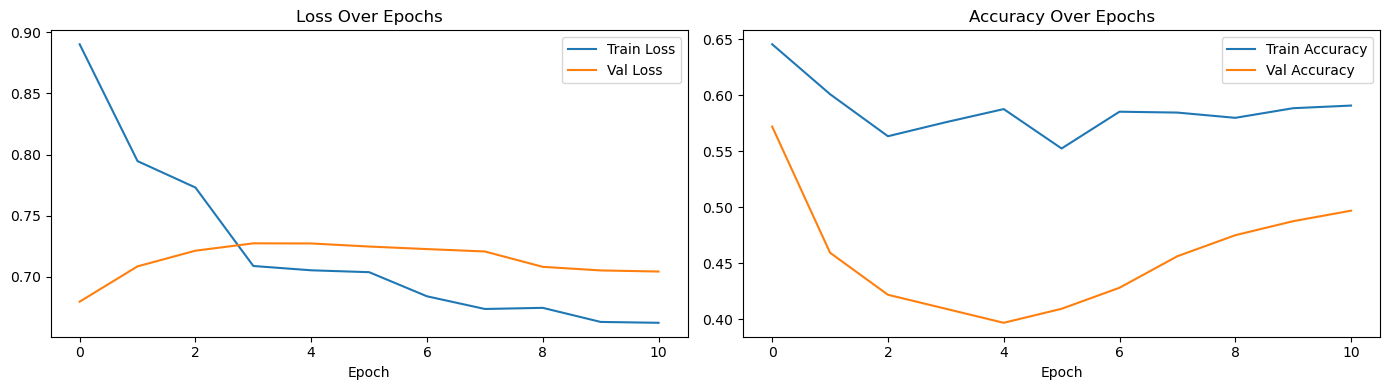

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
tf.random.set_seed(42)
np.random.seed(42)

# Less aggressive class weight
class_weight_dict = {0: 1.0, 1: 2.0}  
print("Using class weights:", class_weight_dict)

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    
    Dense(16, activation='relu'),
    Dropout(0.2),
    
    Dense(8, activation='relu'),
    
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Using class weights: {0: 1.0, 1: 2.0}


c:\Users\SCS-AI-HASSAN-AHMED\miniconda3\envs\machine_learning\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=15,               # more patience this time
    restore_best_weights=True,
    mode='max'                 # maximize AUC, not minimize loss
)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete. Epochs run:", len(history.history['loss']))

Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6414 - auc: 0.5186 - loss: 0.9737 - val_accuracy: 0.6438 - val_auc: 0.5837 - val_loss: 0.6622
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5820 - auc: 0.5235 - loss: 0.9323 - val_accuracy: 0.6062 - val_auc: 0.5824 - val_loss: 0.6807
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5258 - auc: 0.5176 - loss: 0.9285 - val_accuracy: 0.5531 - val_auc: 0.5901 - val_loss: 0.6877
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5320 - auc: 0.5568 - loss: 0.9197 - val_accuracy: 0.5469 - val_auc: 0.6054 - val_loss: 0.6882
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5227 - auc: 0.5417 - loss: 0.9205 - val_accuracy: 0.5531 - val_auc: 0.6191 - val_loss: 0.6880
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5109 - auc: 0.5515 - loss: 0.9188 - val_accuracy: 0.5344 - val_auc: 0.6193 - val_loss: 0.6902
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms

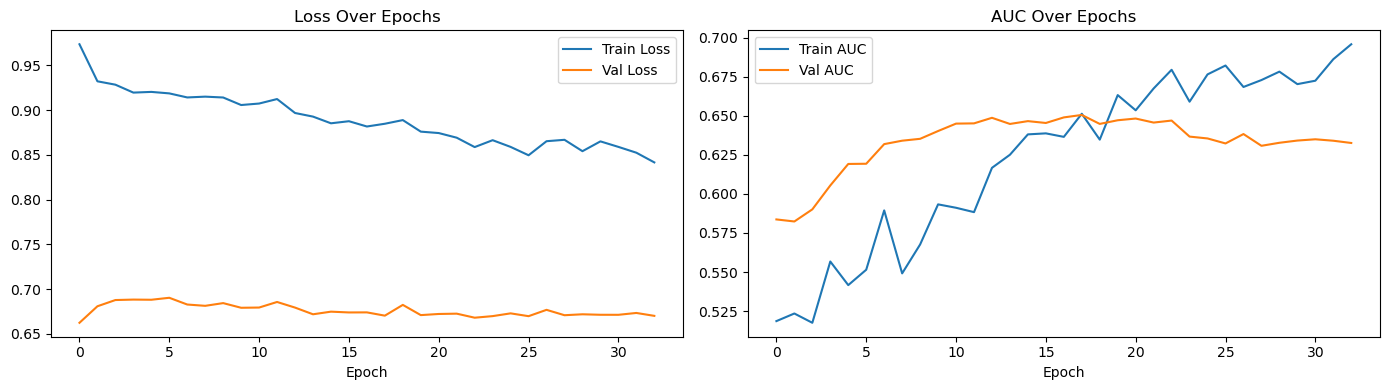

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    Dense(64, activation='relu', 
          kernel_regularizer=l2(0.001),
          input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    
    Dense(32, activation='relu',
          kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    
    Dense(16, activation='relu',
          kernel_regularizer=l2(0.001)),
    
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

early_stop = EarlyStopping(
    monitor='val_auc',
    patience=20,
    restore_best_weights=True,
    mode='max'
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,          # smaller batch = more gradient updates
    validation_split=0.2,
    class_weight={0: 1.0, 1: 2.0},
    callbacks=[early_stop],
    verbose=1
)

print("Epochs run:", len(history.history['loss']))

Epoch 1/200


c:\Users\SCS-AI-HASSAN-AHMED\miniconda3\envs\machine_learning\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6062 - auc: 0.5311 - loss: 1.0478 - val_accuracy: 0.5156 - val_auc: 0.5722 - val_loss: 0.7863
Epoch 2/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5508 - auc: 0.5620 - loss: 1.0087 - val_accuracy: 0.5250 - val_auc: 0.5951 - val_loss: 0.7833
Epoch 3/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5352 - auc: 0.5674 - loss: 1.0033 - val_accuracy: 0.4969 - val_auc: 0.6109 - val_loss: 0.7822
Epoch 4/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5453 - auc: 0.5880 - loss: 0.9935 - val_accuracy: 0.5125 - val_auc: 0.6151 - val_loss: 0.7769
Epoch 5/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5633 - auc: 0.6012 - loss: 0.9840 - val_accuracy: 0.5156 - val_auc: 0.6158 - val_loss: 0.7763
Epoch 6/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5656 - auc: 0.6105 - loss: 0.9790 - val_accuracy: 0.5406 - val_auc: 0.6080 - val_loss: 0.7693
Epoch 7/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accur

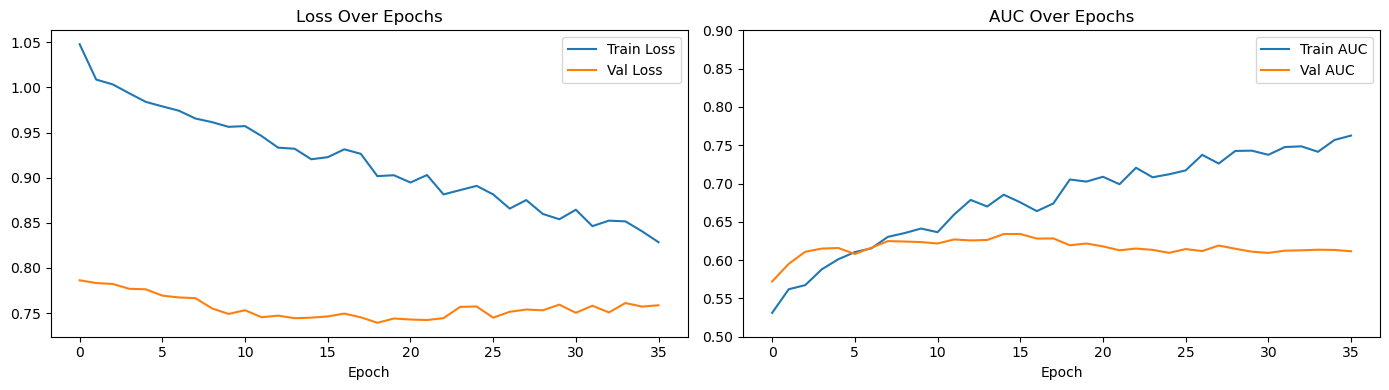

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim([0.5, 0.9])
axes[1].legend()

plt.tight_layout()
plt.show()

In [41]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)

y_prob_ann = model.predict(X_test).flatten()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

print("=== ANN Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_ann):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_ann):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_ann):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred_ann):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_ann):.3f}")

print("\n=== Baseline Comparison ===")
print(results_df.to_string(index=False))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
=== ANN Results ===
Accuracy : 0.527
Precision: 0.393
Recall   : 0.713
F1 Score : 0.507
ROC-AUC  : 0.602

=== Baseline Comparison ===
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.677      0.566   0.221     0.317    0.620
      Random Forest     0.637      0.385   0.110     0.171    0.574
            XGBoost     0.610      0.381   0.235     0.291    0.569


In [42]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_ann)

# Find threshold where F1 is maximized
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold : {best_threshold:.3f}")
print(f"Best Precision : {precisions[best_idx]:.3f}")
print(f"Best Recall    : {recalls[best_idx]:.3f}")
print(f"Best F1        : {f1_scores[best_idx]:.3f}")

Best Threshold : 0.346
Best Precision : 0.368
Best Recall    : 0.934
Best F1        : 0.528


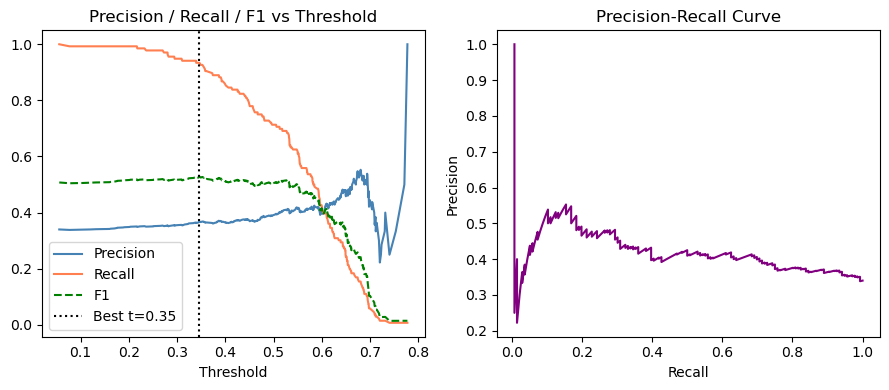

In [43]:
plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='coral')
plt.plot(thresholds, f1_scores[:-1], label='F1', color='green', linestyle='--')
plt.axvline(best_threshold, color='black', linestyle=':', label=f'Best t={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recalls[:-1], precisions[:-1], color='purple')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

=== ANN with Tuned Threshold ===
Threshold  : 0.346
Accuracy   : 0.432
Precision  : 0.368
Recall     : 0.934
F1 Score   : 0.528
ROC-AUC    : 0.602


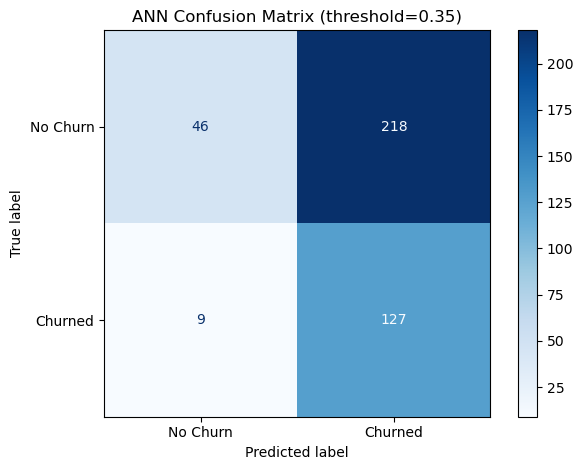

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred_tuned = (y_prob_ann >= best_threshold).astype(int)

print("=== ANN with Tuned Threshold ===")
print(f"Threshold  : {best_threshold:.3f}")
print(f"Accuracy   : {accuracy_score(y_test, y_pred_tuned):.3f}")
print(f"Precision  : {precision_score(y_test, y_pred_tuned):.3f}")
print(f"Recall     : {recall_score(y_test, y_pred_tuned):.3f}")
print(f"F1 Score   : {f1_score(y_test, y_pred_tuned):.3f}")
print(f"ROC-AUC    : {roc_auc_score(y_test, y_prob_ann):.3f}")

cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No Churn', 'Churned'])
disp.plot(cmap='Blues')
plt.title(f'ANN Confusion Matrix (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.show()

In [45]:
import pickle
import os

os.makedirs('churn_model', exist_ok=True)

# Save ANN model
model.save('churn_model/ann_churn_model.keras')

# Save scaler (needed for future predictions)
with open('churn_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save best threshold
with open('churn_model/threshold.pkl', 'wb') as f:
    pickle.dump(best_threshold, f)

print("Saved: ann_churn_model.keras")
print("Saved: scaler.pkl")
print("Saved: threshold.pkl")

Saved: ann_churn_model.keras
Saved: scaler.pkl
Saved: threshold.pkl


In [46]:
final_results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': 0.677, 'Precision': 0.566, 
     'Recall': 0.221, 'F1': 0.317, 'ROC-AUC': 0.620},
    {'Model': 'Random Forest',       'Accuracy': 0.637, 'Precision': 0.385, 
     'Recall': 0.110, 'F1': 0.171, 'ROC-AUC': 0.574},
    {'Model': 'XGBoost',             'Accuracy': 0.610, 'Precision': 0.381, 
     'Recall': 0.235, 'F1': 0.291, 'ROC-AUC': 0.569},
    {'Model': 'ANN (threshold=0.35)','Accuracy': 0.527, 'Precision': 0.368, 
     'Recall': 0.934, 'F1': 0.528, 'ROC-AUC': 0.602},
])

print(final_results.to_string(index=False))

               Model  Accuracy  Precision  Recall    F1  ROC-AUC
 Logistic Regression     0.677      0.566   0.221 0.317    0.620
       Random Forest     0.637      0.385   0.110 0.171    0.574
             XGBoost     0.610      0.381   0.235 0.291    0.569
ANN (threshold=0.35)     0.527      0.368   0.934 0.528    0.602


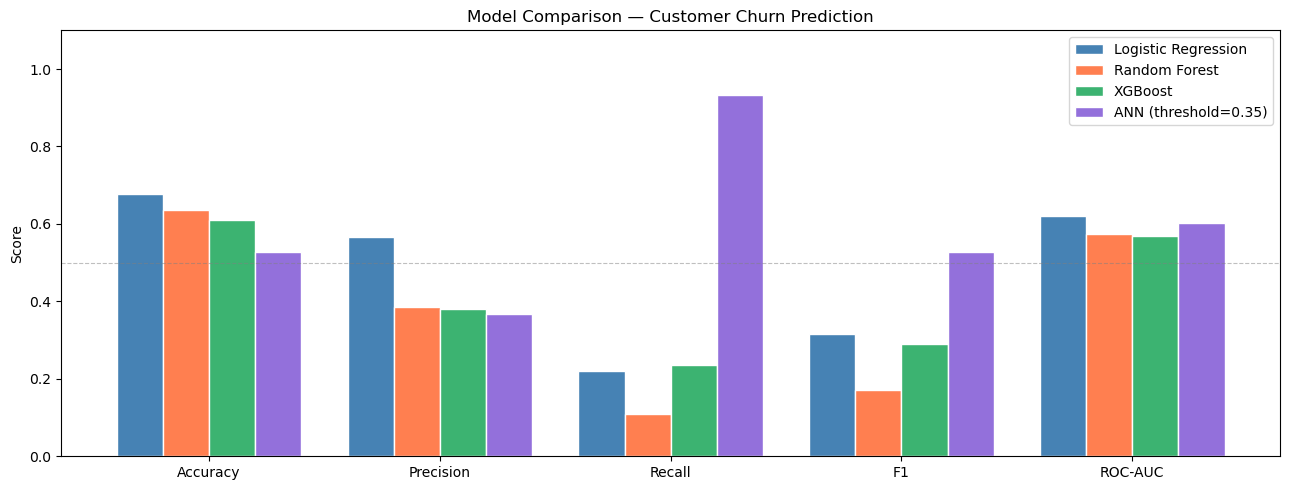

In [47]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(13, 5))

for i, (_, row) in enumerate(final_results.iterrows()):
    ax.bar(x + i * width, row[metrics], width, 
           label=row['Model'], color=colors[i], edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Customer Churn Prediction')
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

In [48]:
# Simulate a new customer — high risk profile
new_customer = pd.DataFrame([{
    'SeniorCitizen': 0, 'Partner': 0, 'Dependents': 0,
    'Tenure': 3, 'PhoneService': 1, 'MultipleLines': 0,
    'OnlineSecurity': 0, 'OnlineBackup': 0, 'DeviceProtection': 0,
    'TechSupport': 0, 'StreamingTV': 1, 'StreamingMovies': 1,
    'PaperlessBilling': 1, 'MonthlyCharges': 85.0, 'TotalCharges': 255.0,
    'AvgMonthlySpend': 85.0,
    'Gender_Male': 1,
    'InternetService_Fiber optic': 1, 'InternetService_No': 0,
    'Contract_One year': 0, 'Contract_Two year': 0,
    'PaymentMethod_Credit card (automatic)': 0,
    'PaymentMethod_Electronic check': 1,
    'PaymentMethod_Mailed check': 0
}])

# Scale numerical columns
new_customer[scale_cols] = scaler.transform(new_customer[scale_cols])

prob = model.predict(new_customer).flatten()[0]
prediction = "🔴 HIGH CHURN RISK" if prob >= best_threshold else "🟢 LIKELY TO STAY"

print(f"Churn Probability : {prob:.3f}")
print(f"Threshold         : {best_threshold:.3f}")
print(f"Prediction        : {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Churn Probability : 0.745
Threshold         : 0.346
Prediction        : 🔴 HIGH CHURN RISK
